# Grover 算法-数学原理及实现
----

## 数学原理

### 1. 初始状态
假设初态为
$$
\left|000\right\rangle
$$
对3个数据量子比特施加 Hadamard 门, 可得
$$
\left|s\right\rangle=H^{\otimes 3}\left|000\right\rangle=\frac{1}{\sqrt{8}}\sum_{x=0}^{7}\left|x\right\rangle
$$
目标态为 $\left|w\right\rangle=\left|101\right\rangle$.

所以初始成功概率为
$$
p=|\left<w|s\right>|^2=\frac{1}{8}
$$
定义
$$
\sin\theta=\frac{1}{\sqrt{8}},\qquad \theta=\arcsin\sin\frac{1}{\sqrt{8}}\approx 0.361367
$$
把均匀叠加态写为二维形式
$$
\left|s\right\rangle=\sin\theta\left|w\right\rangle+\cos\theta\left|w^\perp\right\rangle
$$
Grover 算法实际上只在此二维空间运动.

### 2. Oracle
Oracle 只给目标态翻转相位:
$$
O=I-2\left|w\right\rangle\left\langle w\right|
$$
所以有
$$
O\left|x\right\rangle=\begin{cases}
-\left|x\right\rangle & x=101\\ 
\left|x\right\rangle & x\neq 101
\end{cases}
$$

### 3. Diffuser
扩散算子为
$$
D=2\left|s\right\rangle\left\langle s\right|-I
$$
它是关于 $\left|s\right\rangle$ 的一个反射算子.

因此一次 Grover iteration 是
$$
G=DO
$$
两个 reflection 的乘积就是二维旋转, 所以
$$
G^k\left|s\right\rangle=\sin[(2k+1)\theta]\left|w\right\rangle+\cos[(2k+1)\theta]\left|w^\perp\right\rangle
$$
因此目标概率变为
$$
P_k=\sin^2[(2k+1)\theta]
$$

### 为什么需要两次迭代？
当 $(2k+1)\theta=\frac{\pi}{2}$ 时,$\sin^2((2k+1)\theta)=1$, 成功概率达到 $100\%$,解出 $k$ 可得
$$
k=\frac{\pi}{4\theta}-\frac{1}{2}
$$
最佳迭代次数近似为
$$
k=\left\lfloor\frac{\pi}{4\theta}-\frac{1}{2}\right\rfloor 
$$
这里有
$$
\theta=\arcsin\frac{1}{\sqrt{8}}\quad \Rightarrow \quad k=2
$$
所以成功概率为:
$$
\begin{aligned}
P_0 &= \sin^2\theta=\frac{1}{8}=0.125\\
P_1 &= \sin^2(3\theta)=0.78125\\
P_2 &= \sin^2(5\theta)=0.9453125
\end{aligned}
$$
目标概率从 $12.5\%$ 提升到 $94.53125\%$.

## 代码实现

In [1]:
# 导入 unitarylab 库并检查是否可用
import unitarylab

print("unitarylab_version:", unitarylab.__version__)

unitarylab_version: 1.1.5


[GROVER]: Starting Grover Algorithm
[GROVER]: Input parameters: 
        - Number of qubits (n) = 3
        - Target state (binary string) = 101
[GROVER]: Stage 1/5: Preparing algorithm parameters...
[GROVER]:   - Data register size: n = 3 (total 4 qubits)
[GROVER]:   - Initial success probability p: 0.1250
[GROVER]:   - Computed iteration count (Reps): 2
[GROVER]: Stage 1/5 complete ✓
[GROVER]: Stage 2/5: Building quantum circuit...
[GROVER]: Stage 2/5 complete ✓
[GROVER]: Stage 3/5: Running quantum simulation...
[GROVER]:   - Computation time: 0.0117 s
[GROVER]: Stage 3/5 complete ✓
[GROVER]: Stage 4/5: Running classical post-processing (verifying amplification effect)...
[GROVER]:   - Initial target-state probability: 0.1250
[GROVER]:   - Amplified target-state probability: 0.9453
[GROVER]:   - Result check: find target state 101
[GROVER]: Stage 4/5 complete ✓
[GROVER]: Stage 5/5: Exporting quantum circuit diagram...
[GROVER]: Output information: 
        - Amplified target-state pr

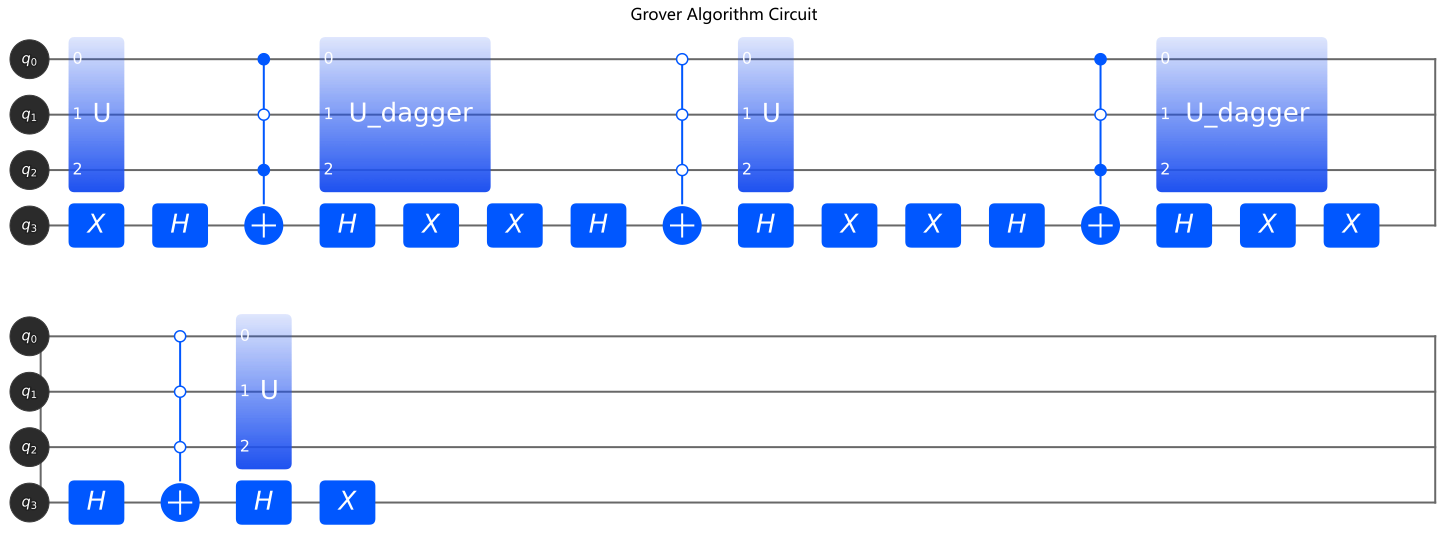

In [ ]:
# 绘制线路图
from IPython.display import SVG, display
from unitarylab_algorithms import GroverAlgorithm

gorver = GroverAlgorithm(text_mode="plain")

result = gorver.run(n=3, target='101', backend='numpy', device='cpu')

print("Status:")
print(result["status"])

print("\nCircuit path:")
print(result["circuit_path"])

display(SVG(filename=result["circuit_path"]))

In [3]:
# 手写数值模拟
import math

import numpy as np

n = 3
N = 2 ** n
target = '101'
target_index = int(target, 2) # 二进制 '101' -> 5

# 初态矢 1/sqrt(8)[1, 1, 1, 1, 1, 1, 1, 1]^T
psi = np.ones(N, dtype=complex) / np.sqrt(N)

# 构建 Oracle
oracle = np.eye(N, dtype=complex)
oracle[target_index, target_index] = -1 # O=diag{1, 1, 1, 1, 1, -1, 1, 1}

# 构建 Diffuser
s = np.ones(N, dtype=complex) / np.sqrt(N)
diffuser = 2 * np.outer(s, s.conj())- np.eye(N, dtype=complex)

# 构建 Grover Operator
G = diffuser @ oracle

# 计算最佳迭代次数
theta = math.asin(1 / math.sqrt(N))
k = round(math.pi / (4 * theta)-1 / 2)

print("\nTheta=", theta)
print("Best iterations=", k)

# 迭代
psi = s.copy()
history = [np.abs(psi) ** 2]

for step in range(k):
    psi = G @ psi

    probabilities = np.abs(psi) ** 2
    history.append(probabilities)

    print(f"After iteration {step + 1}:")
    print("P(101)=", probabilities[target_index])

# 计算最终所有的概率分布
manual_probabilities = np.abs(psi) ** 2

basis_states = [format(i, f"0{n}b") for i in range(N)]

print("\nManual probabilities:")
for state, prob in zip(basis_states, manual_probabilities):
    print(f"|{state}>: {prob:.10f}")

# 找出最后结果
manual_index = np.argmax(manual_probabilities)
manual_state = format(manual_index, f"0{n}b")
manual_target_prob = manual_probabilities[target_index]

print("\nManual state =", manual_state)
print("Manual P(target) =", manual_target_prob)



Theta= 0.3613671239067078
Best iterations= 2
After iteration 1:
P(101)= 0.7812499999999997
After iteration 2:
P(101)= 0.9453124999999996

Manual probabilities:
|000>: 0.0078125000
|001>: 0.0078125000
|010>: 0.0078125000
|011>: 0.0078125000
|100>: 0.0078125000
|101>: 0.9453125000
|110>: 0.0078125000
|111>: 0.0078125000

Manual state = 101
Manual P(target) = 0.9453124999999996


In [4]:
# 官方模拟
algo = GroverAlgorithm()
result = algo.run(n=3, target="101")
is_really_success = result["Result"] == "101"  # 真实成败判断，不要依赖 result['status']

print(is_really_success)
print("Offical state=", result["Result"])
print("Offical P(target)=", result["Amplified target-state probability"])

[GROVER]: Starting Grover Algorithm
[GROVER]: Input parameters: 
        - Number of qubits (n) = 3
        - Target state (binary string) = 101
[GROVER]: Stage 1/5: Preparing algorithm parameters...
[GROVER]:   - Data register size: n = 3 (total 4 qubits)
[GROVER]:   - Initial success probability p: 0.1250
[GROVER]:   - Computed iteration count (Reps): 2
[GROVER]: Stage 1/5 complete ✓
[GROVER]: Stage 2/5: Building quantum circuit...
[GROVER]: Stage 2/5 complete ✓
[GROVER]: Stage 3/5: Running quantum simulation...
[GROVER]:   - Computation time: 0.0825 s
[GROVER]: Stage 3/5 complete ✓
[GROVER]: Stage 4/5: Running classical post-processing (verifying amplification effect)...
[GROVER]:   - Initial target-state probability: 0.1250
[GROVER]:   - Amplified target-state probability: 0.9453
[GROVER]:   - Result check: find target state 101
[GROVER]: Stage 4/5 complete ✓
[GROVER]: Stage 5/5: Exporting quantum circuit diagram...
[GROVER]: Output information: 
        - Amplified target-state pr

In [5]:
# 二者对比
print("\n========== Manual vs Official ==========")

print("Manual state   =", manual_state)
print("Official state =", result["Result"])

print("\nManual probability   =", manual_target_prob)
print("Official probability =", result["Amplified target-state probability"])

error = abs(manual_target_prob - result["Amplified target-state probability"])

print("\nAbsolute error =", error)



========== Manual vs Official ==========
Manual state   = 101
Official state = 101

Manual probability   = 0.9453124999999996
Official probability = 0.9453125000000019

Absolute error = 2.3314683517128287e-15


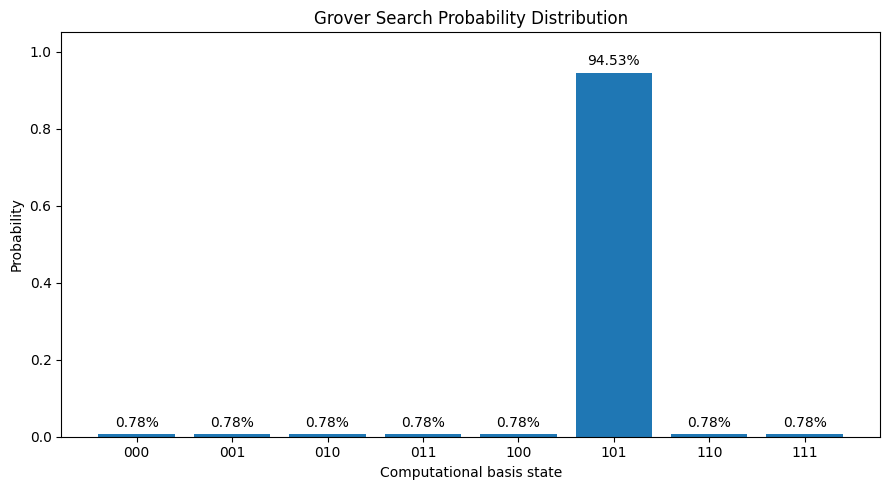

In [13]:
# 绘制概率图
import matplotlib.pyplot as plt

%matplotlib inline
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(basis_states, manual_probabilities)
ax.bar_label(bars, labels=[f"{p * 100:.2f}%" for p in manual_probabilities], padding=3)
ax.set_xlabel("Computational basis state")
ax.set_ylabel("Probability")
ax.set_title("Grover Search Probability Distribution")
ax.set_ylim(0, 1.05)
fig.tight_layout()

plt.show()